# Heart Failure Prediction - Classification Assignment

In this notebook I have solved the classification assignment on the **Heart Failure Clinical Records** dataset.

The aim is to predict whether a patient who suffered from heart failure will **die** or **survive**, based on their clinical records. I followed the full pipeline of data cleaning, exploratory analysis, scaling, balancing, model training and hyperparameter tuning.



## About the Dataset

- The dataset contains **299 patient records** and **13 feature columns**.
- Target column: **DEATH_EVENT**
  - `1` = patient deceased
  - `0` = patient survived
- This is a classic medical binary classification problem taken from Kaggle.



## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')


## 2. Loading the Dataset

In [2]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 3. Understanding the Data

In [3]:
print('Total rows and columns:', df.shape)
df.info()


Total rows and columns: (299, 13)
<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


## 4. Checking Missing Values

In [5]:
df.isnull().sum()


age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

The good news is that this dataset has **no missing values** at all, so we can directly move to the analysis and preprocessing steps without any imputation.

## 5. Exploratory Data Analysis (EDA)

First let me check the distribution of the target variable.

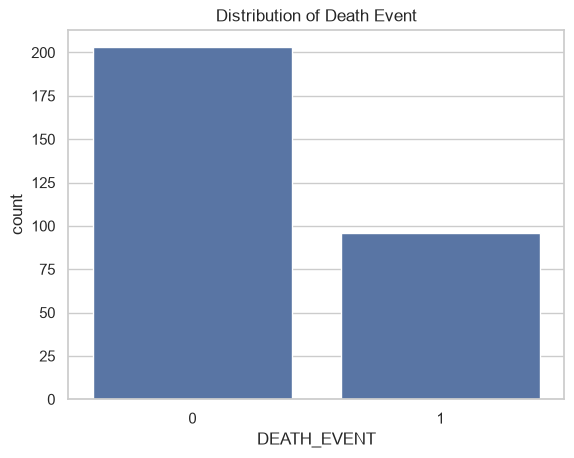

In [6]:
sns.countplot(data=df, x='DEATH_EVENT')
plt.title('Distribution of Death Event')
plt.show()


In [7]:
df['DEATH_EVENT'].value_counts(normalize=True).round(3)


DEATH_EVENT
0    0.679
1    0.321
Name: proportion, dtype: float64

Around 32% of the patients died and 68% survived. The dataset is imbalanced but not extremely, still I will use SMOTE to balance it before training.

Let me also check some relationships between the features and the target.

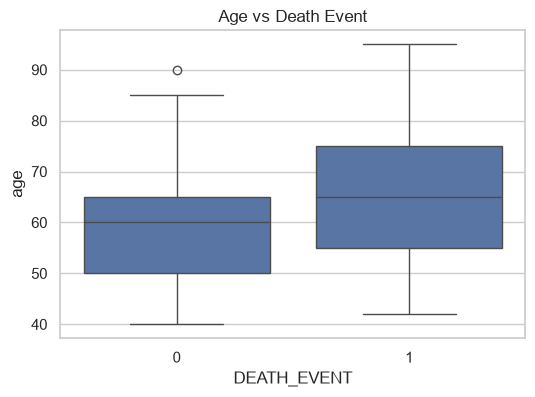

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='DEATH_EVENT', y='age')
plt.title('Age vs Death Event')
plt.show()


In [9]:
# average value of each feature for both classes
df.groupby('DEATH_EVENT').mean().T


DEATH_EVENT,0,1
age,58.761906,65.215281
anaemia,0.408867,0.479167
creatinine_phosphokinase,540.054187,670.197917
diabetes,0.418719,0.416667
ejection_fraction,40.266010,33.468750
high_blood_pressure,0.325123,0.406250
platelets,266657.489901,256381.044792
serum_creatinine,1.184877,1.835833
serum_sodium,137.216749,135.375000
sex,0.650246,0.645833


We can see from the table that patients who died were on average older, had lower ejection fraction, lower serum sodium and higher serum creatinine.

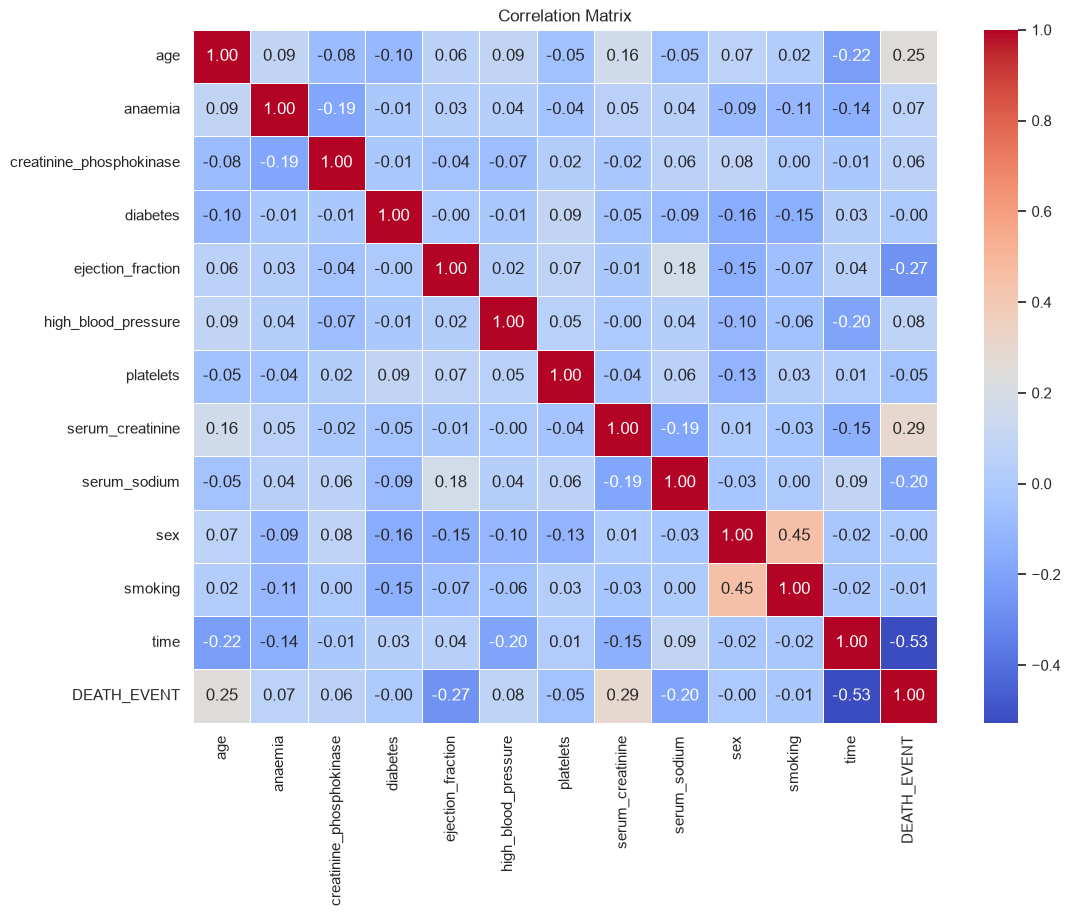

In [10]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


## 6. Train Test Split

Again I am using an 80/20 split with `stratify=y`.

In [11]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)


Train size: (239, 12) | Test size: (60, 12)


## 7. Feature Scaling

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print('Scaling done!')


Scaling done!


## 8. Balancing the Dataset with SMOTE

I applied SMOTE only on the training data to create equal number of samples for both classes.

In [13]:
print('Before SMOTE:', y_train.value_counts().to_dict())
smote = SMOTE(random_state=101)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print('After SMOTE :', y_train_bal.value_counts().to_dict())


Before SMOTE: {0: 162, 1: 77}
After SMOTE : {0: 162, 1: 162}


## 9. Training Different Classification Models

I trained the same set of classifiers on the balanced data and evaluated them on the test set.

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'Naive Bayes': GaussianNB()
}

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    fitted_models[name] = model
    predictions[name] = y_pred
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.816667,0.785714,0.578947,0.666667
1,Gradient Boosting,0.816667,0.750000,0.631579,0.685714
2,Random Forest,0.800000,0.733333,0.578947,0.647059
3,Decision Tree,0.766667,0.631579,0.631579,0.631579
4,SVM,0.733333,0.588235,0.526316,0.555556
5,Naive Bayes,0.716667,0.571429,0.421053,0.484848
6,KNN,0.666667,0.466667,0.368421,0.411765


## 10. Visual Comparison of the Models

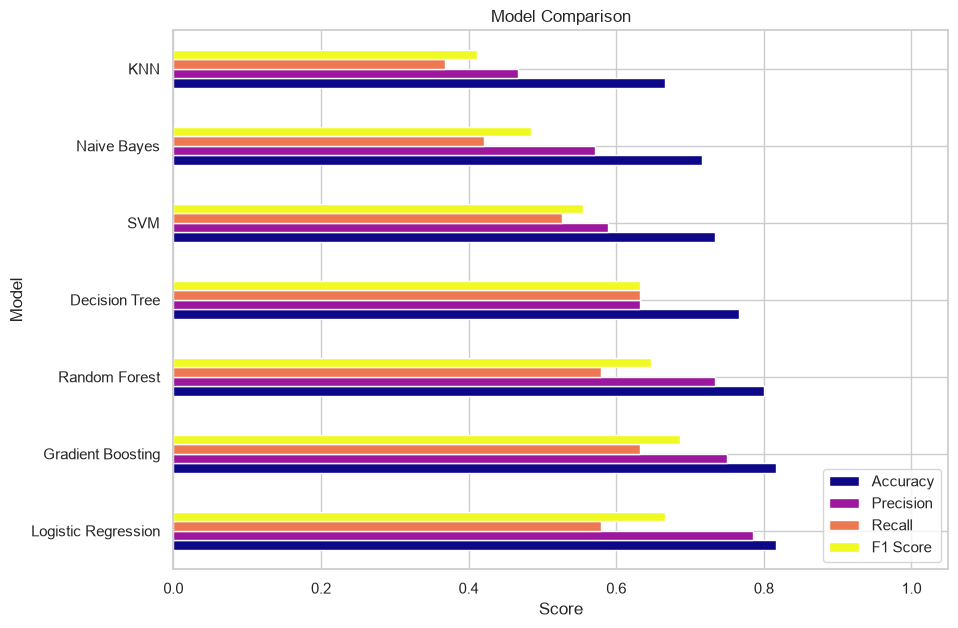

In [15]:
results_df.set_index('Model').plot(kind='barh', figsize=(10, 7), colormap='plasma')
plt.title('Model Comparison')
plt.xlabel('Score')
plt.xlim(0, 1.05)
plt.legend(loc='lower right')
plt.show()


## 11. Detailed Report of the Best Model

In [16]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
y_pred_best = predictions[best_model_name]

print('Best model selected:', best_model_name)
print('Accuracy :', round(accuracy_score(y_test, y_pred_best), 4))
print('Precision:', round(precision_score(y_test, y_pred_best), 4))
print('Recall   :', round(recall_score(y_test, y_pred_best), 4))
print('F1 Score :', round(f1_score(y_test, y_pred_best), 4))


Best model selected: Logistic Regression
Accuracy : 0.8167
Precision: 0.7857
Recall   : 0.5789
F1 Score : 0.6667


In [17]:
print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



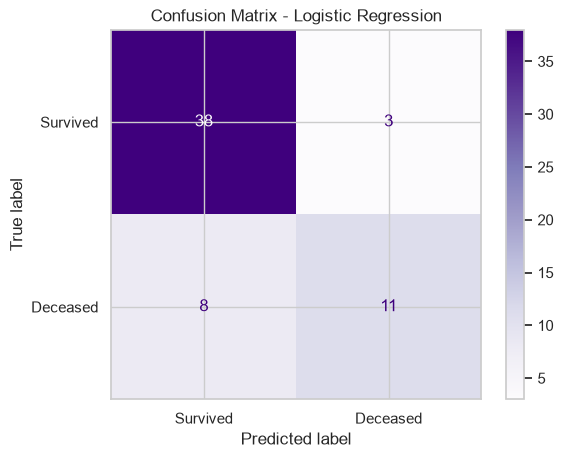

In [18]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Deceased'])
disp.plot(cmap='Purples')
plt.title('Confusion Matrix - ' + best_model_name)
plt.show()


## 12. Hyperparameter Tuning

Random Forest is usually a very strong model on tabular data, so I decided to tune its hyperparameters with GridSearchCV to see if it can beat the current best model and improve the results even further.

In [19]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_bal, y_train_bal)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation accuracy:', round(grid_search.best_score_, 4))


Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation accuracy: 0.8797


## 13. Evaluating the Tuned Model

In [20]:
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print('Accuracy :', round(accuracy_score(y_test, y_pred_tuned), 4))
print('Precision:', round(precision_score(y_test, y_pred_tuned), 4))
print('Recall   :', round(recall_score(y_test, y_pred_tuned), 4))
print('F1 Score :', round(f1_score(y_test, y_pred_tuned), 4))
print()
print(classification_report(y_test, y_pred_tuned))


Accuracy : 0.85
Precision: 0.8571
Recall   : 0.6316
F1 Score : 0.7273

              precision    recall  f1-score   support

           0       0.85      0.95      0.90        41
           1       0.86      0.63      0.73        19

    accuracy                           0.85        60
   macro avg       0.85      0.79      0.81        60
weighted avg       0.85      0.85      0.84        60



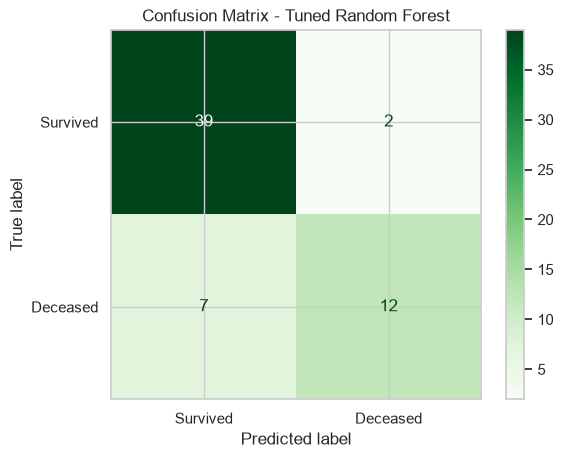

In [21]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Survived', 'Deceased'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()


## 14. Performance Before and After Tuning

In [22]:
rf_default_pred = predictions['Random Forest']
comparison = pd.DataFrame({
    'Model': ['Random Forest (Default)', 'Random Forest (Tuned)'],
    'Accuracy': [accuracy_score(y_test, rf_default_pred), accuracy_score(y_test, y_pred_tuned)],
    'Precision': [precision_score(y_test, rf_default_pred), precision_score(y_test, y_pred_tuned)],
    'Recall': [recall_score(y_test, rf_default_pred), recall_score(y_test, y_pred_tuned)],
    'F1 Score': [f1_score(y_test, rf_default_pred), f1_score(y_test, y_pred_tuned)]
})
comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest (Default),0.80,0.733333,0.578947,0.647059
1,Random Forest (Tuned),0.85,0.857143,0.631579,0.727273


## Conclusion

I performed a complete classification workflow on the heart failure dataset. After scaling the features and balancing the data with SMOTE, I compared 7 different classifiers. **Logistic Regression** had the highest initial accuracy (0.8167), so I tuned **Random Forest** with GridSearchCV to see if it could do better - and it did, reaching **0.85 accuracy** with better Precision, Recall and F1-Score than all the other models.

From the EDA we also learned that `serum_creatinine`, `age`, `ejection_fraction` and `serum_sodium` are the features that differ the most between the patients who survived and those who did not.

